In [8]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Load Dataset
df = pd.read_csv("burnout_dataset.csv")

In [12]:
df.head()

,Sleep_Hours,Screen_Time,Workload_Level,Stress_Score,Careee_Clarity,Burnout_Risk
0,8.0,3,2,3,8,Low
1,7.5,4,2,4,7,Low
2,8.2,3,1,2,9,Low
3,7.0,5,3,4,7,Low
4,8.0,2,2,3,8,Low


In [14]:
# Basic Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sleep_Hours     150 non-null    float64
 1   Screen_Time     150 non-null    int64  
 2   Workload_Level  150 non-null    int64  
 3   Stress_Score    150 non-null    int64  
 4   Careee_Clarity  150 non-null    int64  
 5   Burnout_Risk    150 non-null    object 
dtypes: float64(1), int64(4), object(1)
memory usage: 7.2+ KB


In [16]:
# Check Missing Values (Data Cleaning)
df.isnull().sum()

Sleep_Hours       0
Screen_Time       0
Workload_Level    0
Stress_Score      0
Careee_Clarity    0
Burnout_Risk      0
dtype: int64

In [18]:
# Check Duplicate Records
df.duplicated().sum()

7

In [20]:
df.drop_duplicates(inplace=True)

In [22]:
# statistical summary of all numerical columns
df.describe()

,Sleep_Hours,Screen_Time,Workload_Level,Stress_Score,Careee_Clarity
count,143.000000,143.000000,143.000000,143.000000,143.000000
mean,6.647552,5.944056,3.265734,5.538462,5.790210
std,1.267071,2.378827,1.250076,2.525278,2.229296
min,4.500000,2.000000,1.000000,2.000000,2.000000
25%,5.500000,4.000000,2.000000,3.000000,4.000000
50%,6.500000,6.000000,3.000000,6.000000,7.000000
75%,7.850000,8.000000,4.000000,8.000000,7.000000
max,8.800000,10.000000,5.000000,9.000000,9.000000


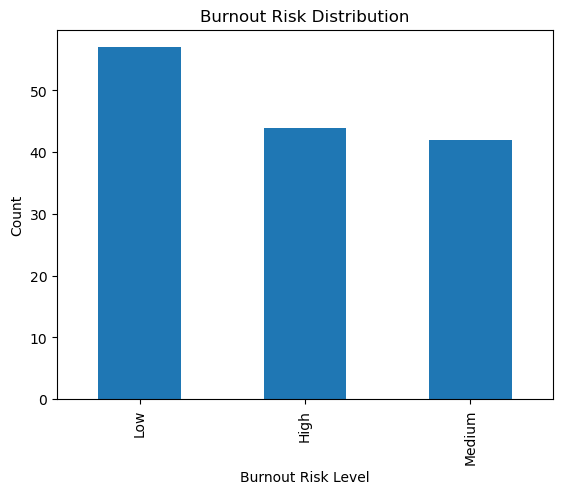

In [24]:
# Exploratory Data Analysis(EDA) – Graphs
# Graph 1: Burnout Risk Distribution
df['Burnout_Risk'].value_counts().plot(kind='bar')
plt.title("Burnout Risk Distribution")
plt.xlabel("Burnout Risk Level")
plt.ylabel("Count")
plt.show()


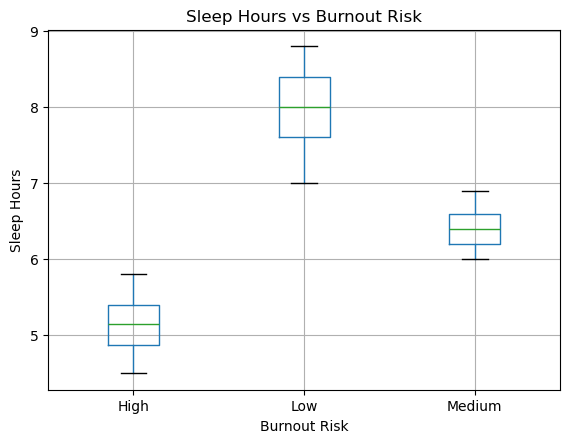

In [26]:
# Graph 2: Sleep Hours vs Burnout Risk
df.boxplot(column='Sleep_Hours', by='Burnout_Risk')
plt.title("Sleep Hours vs Burnout Risk")
plt.suptitle("")
plt.xlabel("Burnout Risk")
plt.ylabel("Sleep Hours")
plt.show()


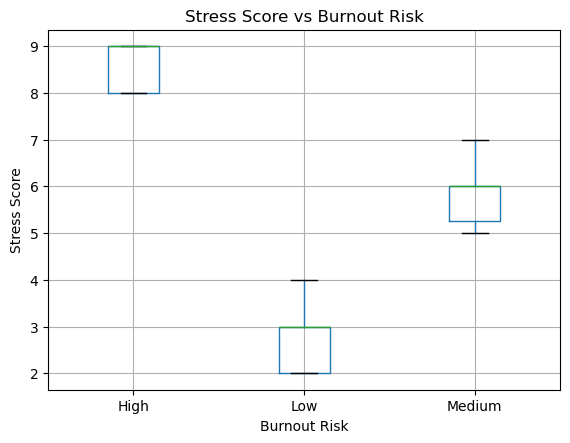

In [28]:
# Graph 3: Stress Score vs Burnout Risk
df.boxplot(column='Stress_Score', by='Burnout_Risk')
plt.title("Stress Score vs Burnout Risk")
plt.suptitle("")
plt.xlabel("Burnout Risk")
plt.ylabel("Stress Score")
plt.show()


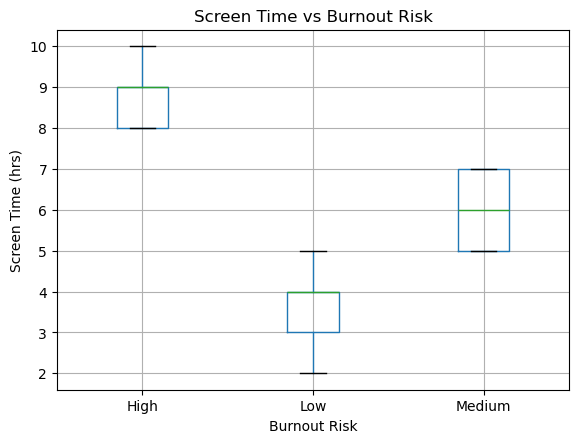

In [30]:
# Graph 4: Screen Time vs Burnout Risk
df.boxplot(column='Screen_Time', by='Burnout_Risk')
plt.title("Screen Time vs Burnout Risk")
plt.suptitle("")
plt.xlabel("Burnout Risk")
plt.ylabel("Screen Time (hrs)")
plt.show()


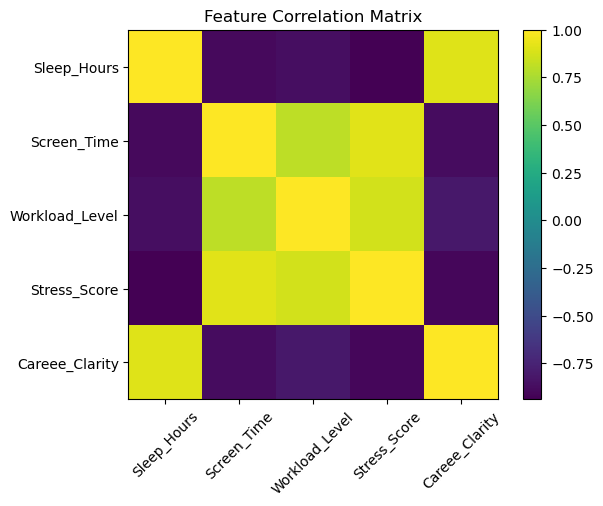

In [32]:
# Graph 5: Correlation Heatmap
corr = df.drop("Burnout_Risk", axis=1).corr()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Matrix")
plt.show()


In [34]:
# Machine Learning Model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier


In [36]:
df.head()

,Sleep_Hours,Screen_Time,Workload_Level,Stress_Score,Careee_Clarity,Burnout_Risk
0,8.0,3,2,3,8,Low
1,7.5,4,2,4,7,Low
2,8.2,3,1,2,9,Low
3,7.0,5,3,4,7,Low
4,8.0,2,2,3,8,Low


In [38]:
# Load Cleaned Dataset
df.to_csv("Cleaned_Burnout_Dataset.csv", index=False)


In [40]:
import os
os.listdir()


['.ipynb_checkpoints',
 'burnout_dataset.csv',
 'burnout_model.pkl',
 'CBP.ipynb',
 'Cleaned_Burnout_Dataset.csv',
 'EDA_Netflix.ipynb',
 'netflix.csv',
 'OracleXE213_Win64.zip',
 'TYminip',
 'Untitled.ipynb']

In [42]:
# Create Burnout Risk Score (0–100 scale concept)
df["Burnout_Score"] = (
    df["Stress_Score"] * 10 +
    (10 - df["Sleep_Hours"]) * 5 +
    df["Screen_Time"] * 4 +
    df["Workload_Level"] * 8
)

# Normalize score between 0–100
df["Burnout_Score"] = (df["Burnout_Score"] - df["Burnout_Score"].min()) / \
                      (df["Burnout_Score"].max() - df["Burnout_Score"].min()) * 100

df.head()

,Sleep_Hours,Screen_Time,Workload_Level,Stress_Score,Careee_Clarity,Burnout_Risk,Burnout_Score
0,8.0,3,2,3,8,Low,15.686275
1,7.5,4,2,4,7,Low,26.470588
2,8.2,3,1,2,9,Low,3.267974
3,7.0,5,3,4,7,Low,35.947712
4,8.0,2,2,3,8,Low,13.071895


In [52]:
# Separate Features & Target
X = df.drop("Burnout_Risk", axis=1)
y = df["Burnout_Risk"]


In [54]:
# Encode Target Labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)



In [56]:
# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


In [58]:
# Train the Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

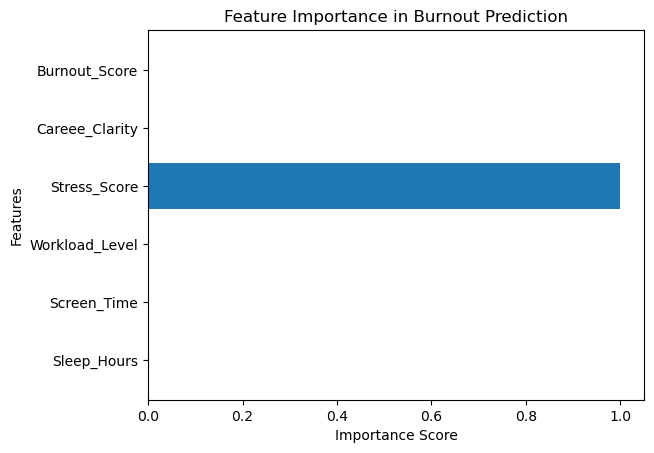

In [60]:
# Feature Importance Visualization
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, feature_importances)
plt.title("Feature Importance in Burnout Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [62]:
# Make Predictions
y_pred = model.predict(X_test)


In [64]:
# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 1.0


In [66]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         9

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



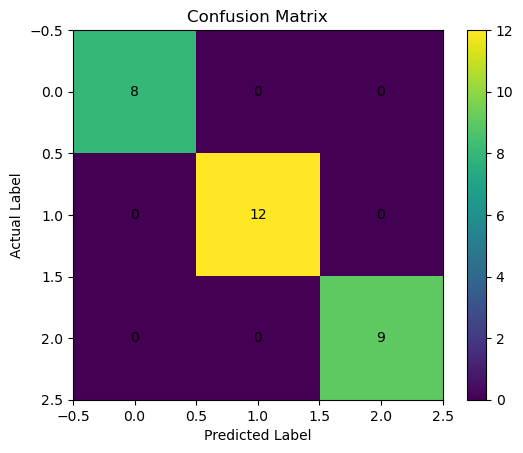

In [68]:
# Confusion Matrix Visualization
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

# Add numbers inside matrix
for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [ ]:
# The model successfully learns behavioral patterns associated with burnout risk and provides acceptable prediction accuracy

In [70]:
# Save the Model
import joblib
joblib.dump(model, "burnout_model.pkl")


['burnout_model.pkl']

In [72]:
# This part of code tells WHY the model predicts a certain burnout level.
# Map Numeric Predictions Back to Labels 
label_map = {
    0: "Low Burnout",
    1: "Medium Burnout",
    2: "High Burnout"
}


sample = X_test.iloc[[0]]   # double brackets keep it in DataFrame form
actual = y_test.iloc[0] if hasattr(y_test, "iloc") else y_test[0]
predicted = model.predict(sample)[0]


print("Actual Burnout Level:", label_map[actual])
print("Predicted Burnout Level:", label_map[predicted])


Actual Burnout Level: Low Burnout
Predicted Burnout Level: Low Burnout


In [74]:
# Show Input Values
sample

,Sleep_Hours,Screen_Time,Workload_Level,Stress_Score,Careee_Clarity,Burnout_Score
124,5.4,10,4,9,3,92.156863


In [76]:
# Convert Explanation into Rule-Based Logic
def explain_prediction(row):
    reasons = []

    if row["Sleep_Hours"] < 6:
        reasons.append("Low sleep duration")

    if row["Stress_Score"] > 7:
        reasons.append("High stress level")

    if row["Screen_Time"] > 8:
        reasons.append("Excessive screen time")

    if row["Workload_Level"] > 4:
        reasons.append("High workload")

    if len(reasons) == 0:
        reasons.append("Healthy work-life balance indicators")

    return reasons


In [78]:
# provides human-readable reasons for the burnout prediction by analyzing key contributing features.
sample = X_test.iloc[0]
reasons = explain_prediction(sample)

print("Reasons for Prediction:")
for r in reasons:
    print("-", r)


Reasons for Prediction:
- Low sleep duration
- High stress level
- Excessive screen time


In [82]:
# Create Recommendation Function
def generate_recommendations(row, burnout_level):
    recommendations = []

    if burnout_level == "High":
        recommendations.append("Immediate lifestyle changes are recommended.")

    if row["Sleep_Hours"] < 6:
        recommendations.append("Increase sleep to at least 7–8 hours daily.")

    if row["Stress_Score"] > 7:
        recommendations.append("Practice stress-relief techniques like meditation or exercise.")

    if row["Screen_Time"] > 8:
        recommendations.append("Reduce screen time and take regular digital breaks.")

    if row["Workload_Level"] > 4:
        recommendations.append("Try workload prioritization and task scheduling.")

    
    if row["Careee_Clarity"] < 5:
        recommendations.append("Consider career counseling or skill planning sessions.")

    if len(recommendations) == 0:
        recommendations.append("Maintain your current healthy routine.")

    return recommendations


In [84]:
# Create Recommendation Function
sample = X_test.iloc[0]
sample_df = pd.DataFrame([sample], columns=X.columns)
predicted_label = model.predict(sample_df)[0]


label_map = {0: "Low", 1: "Medium", 2: "High"}
burnout_level = label_map[predicted_label]

recs = generate_recommendations(sample, burnout_level)

print("Burnout Level:", burnout_level)
print("Recommended Actions:")
for r in recs:
    print("-", r)


Burnout Level: Low
Recommended Actions:
- Increase sleep to at least 7–8 hours daily.
- Practice stress-relief techniques like meditation or exercise.
- Reduce screen time and take regular digital breaks.
- Consider career counseling or skill planning sessions.


In [88]:
#  Final model testing and validation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [90]:
df = pd.read_csv("Cleaned_Burnout_Dataset.csv")
df.head()


,Sleep_Hours,Screen_Time,Workload_Level,Stress_Score,Careee_Clarity,Burnout_Risk
0,8.0,3,2,3,8,Low
1,7.5,4,2,4,7,Low
2,8.2,3,1,2,9,Low
3,7.0,5,3,4,7,Low
4,8.0,2,2,3,8,Low


In [92]:
X = df.drop("Burnout_Risk", axis=1)
y = df["Burnout_Risk"]


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [96]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [98]:
y_pred = model.predict(X_test)


In [100]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       1.00      1.00      1.00        12
      Medium       1.00      1.00      1.00         9

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



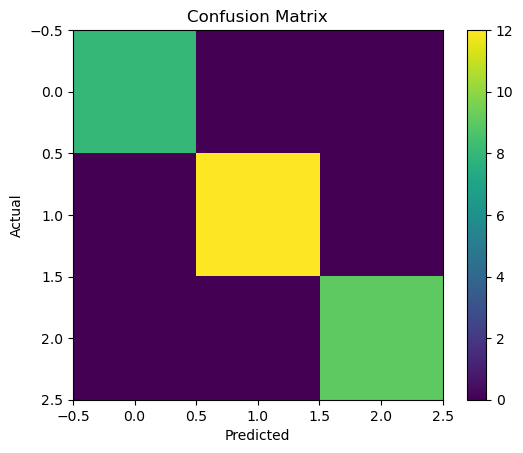

In [102]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


In [104]:
sample = X_test.iloc[0]

sample_df = pd.DataFrame([sample], columns=X.columns)

predicted_label = model.predict(sample_df)[0]

print("Predicted Burnout Level:", predicted_label)


Predicted Burnout Level: High


In [106]:
def explain_prediction(row):
    reasons = []
    if row["Sleep_Hours"] < 6:
        reasons.append("Low sleep duration")
    if row["Stress_Score"] > 7:
        reasons.append("High stress level")
    if row["Screen_Time"] > 8:
        reasons.append("Excessive screen time")
    if row["Workload_Level"] > 4:
        reasons.append("High workload")
    return reasons


In [108]:
reasons = explain_prediction(sample)

print("Explanation:")
for r in reasons:
    print("-", r)


Explanation:
- Low sleep duration
- High stress level
- Excessive screen time


In [110]:
def generate_recommendations(row, burnout_level):
    recommendations = []

    if row["Sleep_Hours"] < 7:
        recommendations.append("Increase sleep to at least 7–8 hours daily.")
    if row["Stress_Score"] > 6:
        recommendations.append("Practice stress-relief techniques like meditation or exercise.")
    if row["Screen_Time"] > 7:
        recommendations.append("Reduce screen time and take regular digital breaks.")
    if row["Workload_Level"] > 4:
        recommendations.append("Try workload prioritization and task scheduling.")
    #if row["Career_Clarity"] < 5:
    if row["Careee_Clarity"] < 5:
        recommendations.append("Consider career counseling or skill planning sessions.")

    if burnout_level == "High":
        recommendations.append("Immediate professional support is recommended.")

    return recommendations


In [112]:
recs = generate_recommendations(sample, burnout_level)

print("Recommended Actions:")
for r in recs:
    print("-", r)


Recommended Actions:
- Increase sleep to at least 7–8 hours daily.
- Practice stress-relief techniques like meditation or exercise.
- Reduce screen time and take regular digital breaks.
- Consider career counseling or skill planning sessions.
